# RNN 梯度流动实验

目标：用 PyTorch 复现《深度学习进阶》第 6.1 节中的 RNN 梯度消失 / 梯度爆炸现象，并理解反复乘以同一个隐藏权重矩阵 `Wh.T` 对梯度范数的影响。

## 1. 原始实验思路

书中 NumPy 脚本的核心是反复执行 `dh = dh @ Wh.T`，模拟简单 RNN 在时间方向上的反向梯度传播。

本 notebook 不重复实现完整 NumPy 版本，而是直接用 PyTorch 复现并扩展这个实验。

In [1]:
import torch

import matplotlib.pyplot as plt

## 2. PyTorch 手动传播版本

- 设置 `N=2`, `H=3`, `T=20`
- 初始化 `dh = torch.ones(N, H)`
- 生成 `Wh`
- 保持与原实验相同的矩阵乘法逻辑
- 记录每一步的平均 L2 范数：`sqrt(sum(dh ** 2)) / N`
- 分别测试 `Wh = randn(...)` 和 `Wh = randn(...) * 0.5`

In [2]:
N = 2  # mini-batch的大小
H = 3  # 隐藏状态向量的维数
T = 20  # 时序数据的长度

torch.manual_seed(42)

dh = torch.ones((N, H))
Wh = torch.randn((H, H))

In [3]:
def backward(dh, Wh):
    norm_list = []
    for t in range(T):
        dh = dh @ Wh.T
        norm = torch.sqrt(torch.sum(dh**2)) / N
        norm_list.append(norm)
    
    return norm_list

In [4]:
backward(dh, Wh)

[tensor(1.7003),
 tensor(2.3852),
 tensor(2.0008),
 tensor(3.2975),
 tensor(2.6391),
 tensor(4.5864),
 tensor(3.6094),
 tensor(6.4968),
 tensor(5.1491),
 tensor(9.3820),
 tensor(7.6687),
 tensor(13.8057),
 tensor(11.8397),
 tensor(20.6698),
 tensor(18.7448),
 tensor(31.4174),
 tensor(30.1258),
 tensor(48.3587),
 tensor(48.7920),
 tensor(75.1951)]

## 3. 观察 scale 对梯度范数的影响

- 尝试多个缩放系数，例如 `0.2`, `0.5`, `1.0`, `1.5`
- 将多条曲线画在同一张图上
- 观察哪些设置更容易导致梯度消失，哪些更容易导致梯度爆炸

In [5]:
norms = {}
scale_list = [0.2, 0.5, 1.0, 1.5]
for scale in scale_list:
    scaled_Wh = Wh * scale
    norm_list = backward(dh, scaled_Wh)
    norms[f"scale={scale}"] = norm_list
    print(f"scale={scale}时，最后一个norm_list为 {norm_list[-1]}")

scale=0.2时，最后一个norm_list为 7.884773563227032e-13
scale=0.5时，最后一个norm_list为 7.17116126907058e-05
scale=1.0时，最后一个norm_list为 75.19507598876953
scale=1.5时，最后一个norm_list为 250042.828125


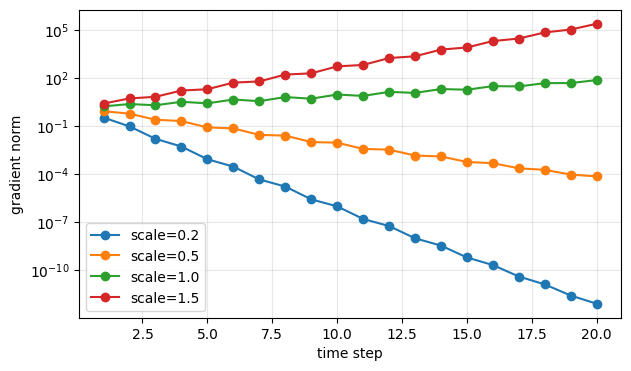

In [6]:
x = range(1, T + 1)

plt.figure(figsize=(7, 4))

for label, norm_list in norms.items():
    plt.plot(x, norm_list, marker="o", label=label)

plt.yscale("log")
plt.xlabel("time step")
plt.ylabel("gradient norm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. 关联最大奇异值

- 对每个 `Wh` 计算最大奇异值 `sigma_max`
- 观察 `sigma_max > 1` 时梯度是否倾向于变大
- 观察 `sigma_max < 1` 时梯度是否倾向于变小
- 注意：最大奇异值是判断趋势的参考，不是绝对充分条件

In [7]:
for scale in scale_list:
    singular_values = torch.linalg.svdvals(Wh * scale)
    sigma_max = singular_values.max()
    print(f"scale = {scale}, sigma_max={sigma_max.item()}")

scale = 0.2, sigma_max=0.4849454164505005
scale = 0.5, sigma_max=1.212363600730896
scale = 1.0, sigma_max=2.424727201461792
scale = 1.5, sigma_max=3.6370904445648193


## 5. 可选：用 autograd 验证直觉

- 构造一个极简 recurrence：`h_t = h_{t-1} @ Wh`
- 定义简单 loss，例如最后一步 hidden state 的平方和
- 调用 `loss.backward()`
- 观察早期 hidden state 或 `Wh.grad` 的梯度规模
- 对比手动传播实验，理解 PyTorch 自动微分背后的链式法则

In [8]:
Wh_auto = Wh.detach().clone().requires_grad_(True)

h = torch.randn((N, H), requires_grad=True)
states = [h]

for t in range(T):
    h = states[-1] @ Wh_auto
    h.retain_grad()
    states.append(h)

loss = torch.sum(states[-1] ** 2)
loss.backward()

for t, state in enumerate(states):
    print(t, state.grad.norm().item() / N)

print("Wh.grad norm:", Wh_auto.grad.norm().item())


0 35318.7421875
1 28753.111328125
2 21862.78515625
3 17949.916015625
4 13522.0703125
5 11221.12890625
6 8355.185546875
7 7027.296875
8 5156.8837890625
9 4411.2080078125
10 3179.0830078125
11 2777.5498046875
12 1957.5751953125
13 1755.9801025390625
14 1204.3934326171875
15 1116.031005859375
16 740.9700927734375
17 714.245361328125
18 456.6178894042969
19 462.2597961425781
20 282.20751953125
Wh.grad norm: 2753779.25


## 小结问题

- 为什么简单 RNN 反向传播时会反复乘以同一个 `Wh.T`？
- 梯度爆炸和梯度消失分别会如何影响训练？
- 梯度裁剪解决的是哪个问题？
- LSTM / GRU 为什么能缓解长期依赖中的梯度消失？